# 05 &mdash; GJR-GARCH(1,1)-t Deployment Model

The benchmark (notebooks 01–04) concluded that the nine top models are
statistically indistinguishable on *point* forecasts. So how do we
choose one for deployment?

**The tiebreaker is prediction intervals.** Simple baselines (Naïve,
RWD, ETS, Theta) produce point forecasts only, or intervals that assume
constant variance and therefore ignore volatility regimes. GARCH-family
models give *calibrated* prediction intervals that adapt to market
stress. For a forecast intended for practical use &mdash; hedging or
procurement planning &mdash; interval calibration matters more than a
small difference in point MAE.

This notebook validates each modeling choice with a statistical test:

| Decision | Justified by |
|---|---|
| Model log-returns, not prices | ADF test (already shown in notebook 04) |
| Constant mean, not AR | HAC-robust t-stat on the drift |
| Student-t innovations, not Normal | Excess kurtosis ~ 6.6; Jarque-Bera |
| GARCH family over IID | ARCH LM test; ACF of squared returns |
| GJR over plain GARCH | AIC, BIC, Ljung-Box on squared residuals |
| Expanding-window backtest | 60-origin empirical coverage check |

## 1. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arch import arch_model
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from coffee_forecast import load_coffee_data, forecast, std_t_ppf, plot_forecast
from coffee_forecast.config import FIG_DIR, FORECASTS_DIR, HORIZON, CONTEXT_LEN

FIG_DIR.mkdir(parents=True, exist_ok=True)
FORECASTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = load_coffee_data()
prices = df["y"].values.astype(float)
log_returns = np.log(df["y"]).diff().dropna().values
print(f"{len(prices)} prices  ({df['ds'].min().date()} → {df['ds'].max().date()})")
print(f"{len(log_returns)} daily log-returns")

8104 prices  (1994-01-03 → 2026-01-30)
8103 daily log-returns


## 2. Drift test &mdash; does coffee have a statistically significant trend?

Coffee prices have risen substantially over 32 years, but *daily* returns
average only +0.019%/day &mdash; around 4.7% annualized, which sounds like
real drift. To check whether that's actually significant we use HAC-robust
standard errors (Newey-West), which correct for any autocorrelation or
heteroskedasticity in the return series.

In [3]:
import statsmodels.api as sm

y = log_returns
X = np.ones_like(y)  # regression on a constant = mean
res_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 10})

mu, se = res_hac.params[0], res_hac.bse[0]
t_stat, p_val = mu / se, res_hac.pvalues[0]
print(f"Mean daily log-return:   {mu:+.6f}")
print(f"HAC standard error:      {se:.6f}")
print(f"t-stat:                  {t_stat:+.3f}")
print(f"p-value (HAC):           {p_val:.3f}")
verdict = "not significant" if p_val > 0.05 else "significant"
print(f"\n→ Drift is statistically {verdict} at 5%. Use a constant-mean model.")

Mean daily log-return:   +0.000188
HAC standard error:      0.000255
t-stat:                  +0.737
p-value (HAC):           0.461

→ Drift is statistically not significant at 5%. Use a constant-mean model.


## 3. Distribution fit &mdash; Normal vs. Student-t

Daily log-returns famously have fat tails. Before choosing a GARCH
innovation distribution, we quantify just how fat they are.

In [4]:
skew = stats.skew(log_returns)
kurt = stats.kurtosis(log_returns, fisher=True)  # 0 under Normal
jb, jb_p = stats.jarque_bera(log_returns)
print(f"Skewness:          {skew:+.3f}")
print(f"Excess kurtosis:   {kurt:+.3f}  (Normal = 0)")
print(f"Jarque-Bera stat:  {jb:.1f}  (p = {jb_p:.2e})")
print("\n→ Excess kurtosis of ~6.6 is wildly non-Normal. Use Student-t.")

Skewness:          +0.186
Excess kurtosis:   +6.648  (Normal = 0)
Jarque-Bera stat:  14970.2  (p = 0.00e+00)

→ Excess kurtosis of ~6.6 is wildly non-Normal. Use Student-t.


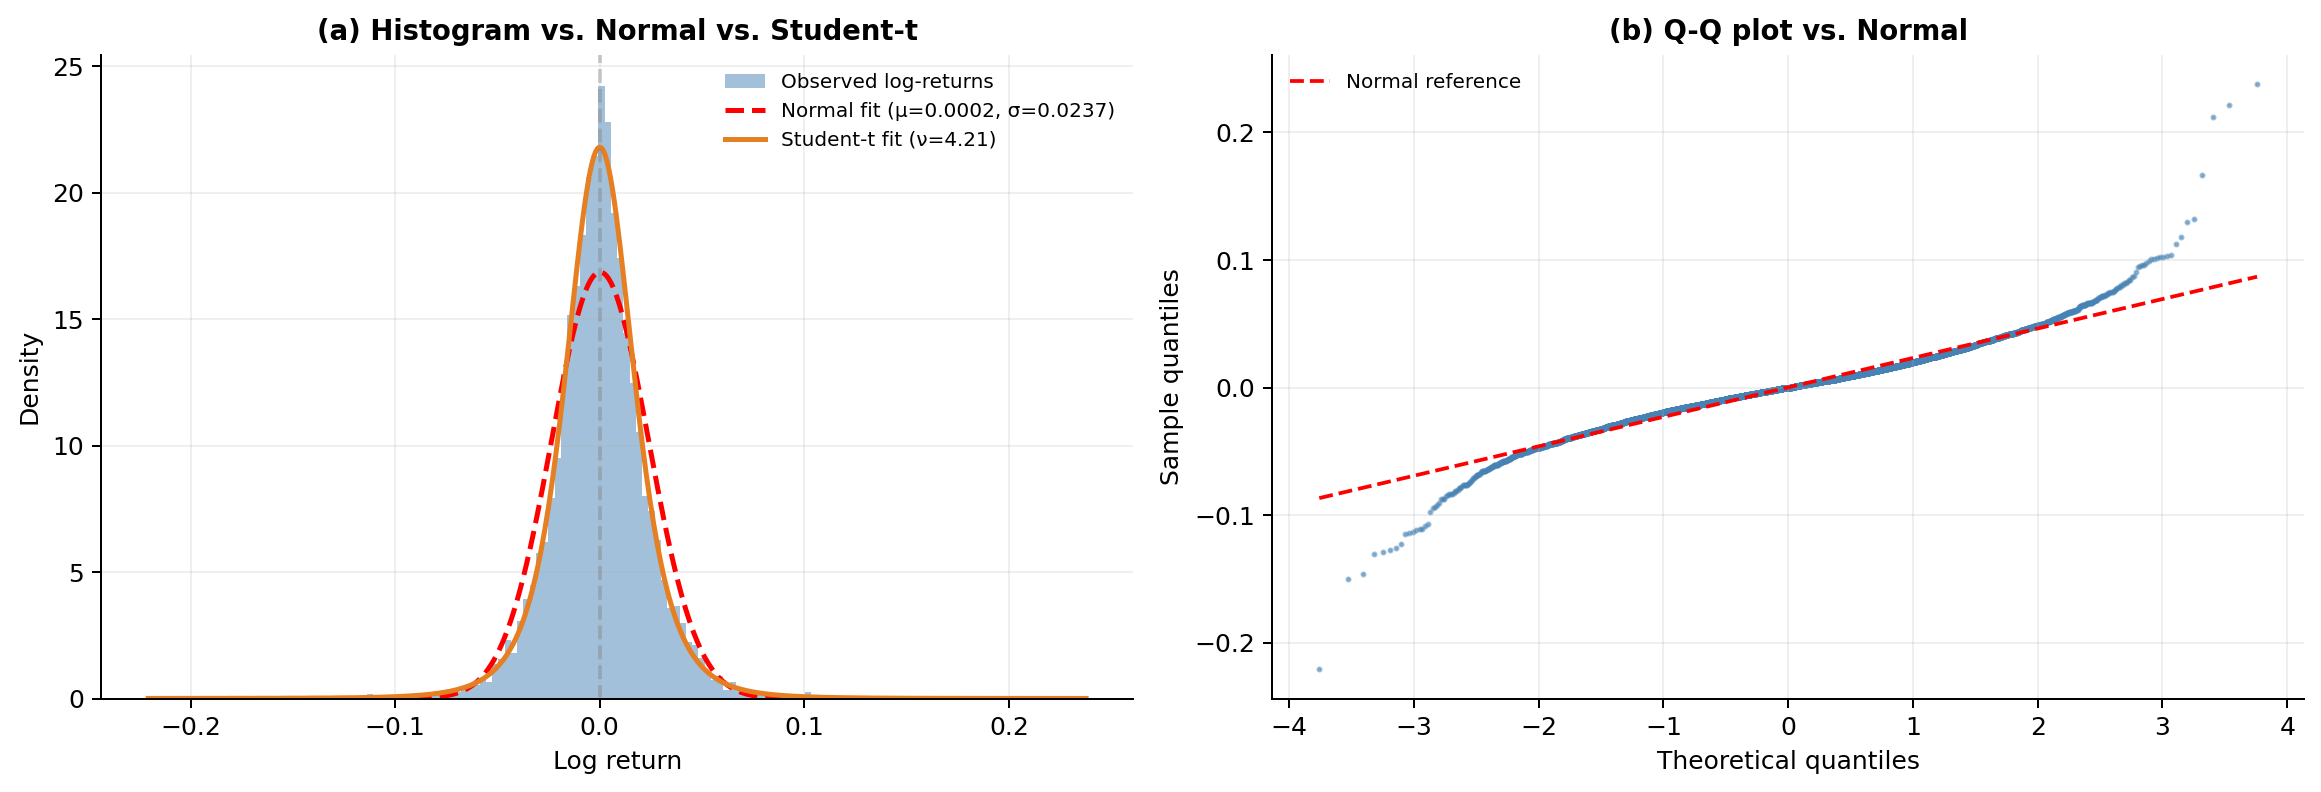

Fitted Student-t ν = 4.21  →  tails substantially heavier than Normal.


In [5]:
nu_fit, t_loc, t_scale = stats.t.fit(log_returns)
mu_norm, std_norm = stats.norm.fit(log_returns)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=180)

# Panel (a): histogram with Normal and Student-t overlays
ax = axes[0]
x_grid = np.linspace(log_returns.min(), log_returns.max(), 500)
ax.hist(
    log_returns,
    bins=150,
    density=True,
    alpha=0.5,
    color="steelblue",
    label="Observed log-returns",
)
ax.plot(
    x_grid,
    stats.norm.pdf(x_grid, mu_norm, std_norm),
    "r--",
    lw=2,
    label=f"Normal fit (\u03bc={mu_norm:.4f}, \u03c3={std_norm:.4f})",
)
ax.plot(
    x_grid,
    stats.t.pdf(x_grid, nu_fit, t_loc, t_scale),
    color="#E67E22",
    lw=2,
    label=f"Student-t fit (\u03bd={nu_fit:.2f})",
)
ax.axvline(0, color="gray", ls="--", alpha=0.4)
ax.set_title("(a) Histogram vs. Normal vs. Student-t", fontsize=11, weight="semibold")
ax.set_xlabel("Log return")
ax.set_ylabel("Density")
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel (b): Q-Q vs Normal
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(log_returns, dist="norm")
ax.scatter(osm, osr, s=2, color="steelblue", alpha=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, "r--", lw=1.5, label="Normal reference")
ax.set_title("(b) Q-Q plot vs. Normal", fontsize=11, weight="semibold")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "returns_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    f"Fitted Student-t \u03bd = {nu_fit:.2f}  \u2192  tails substantially heavier than Normal."
)

> The histogram shows the data's peak is higher than Normal and the
> tails are fatter; the Q-Q plot's S-shape at the extremes is the
> classic fingerprint of heavy tails. The Student-t fit with ν ≈ 4.2
> absorbs this tail mass in a single parameter. This is what motivates
> Student-t innovations in the GARCH specification below.

## 4. ARCH test &mdash; is there volatility clustering?

Engle's (1982) ARCH LM test checks whether squared returns have
detectable autocorrelation. A rejection at 5% says there's detectable
volatility clustering &mdash; a necessary condition for GARCH to be better
than an IID model.

In [6]:
lm_stat, lm_p, _, _ = het_arch(log_returns, nlags=10)
print(f"ARCH LM test (10 lags):  statistic = {lm_stat:.1f},  p = {lm_p:.2e}")
print(
    "\n→ Strongly reject the null of no volatility clustering. GARCH family is appropriate."
)

ARCH LM test (10 lags):  statistic = 523.2,  p = 4.96e-106

→ Strongly reject the null of no volatility clustering. GARCH family is appropriate.


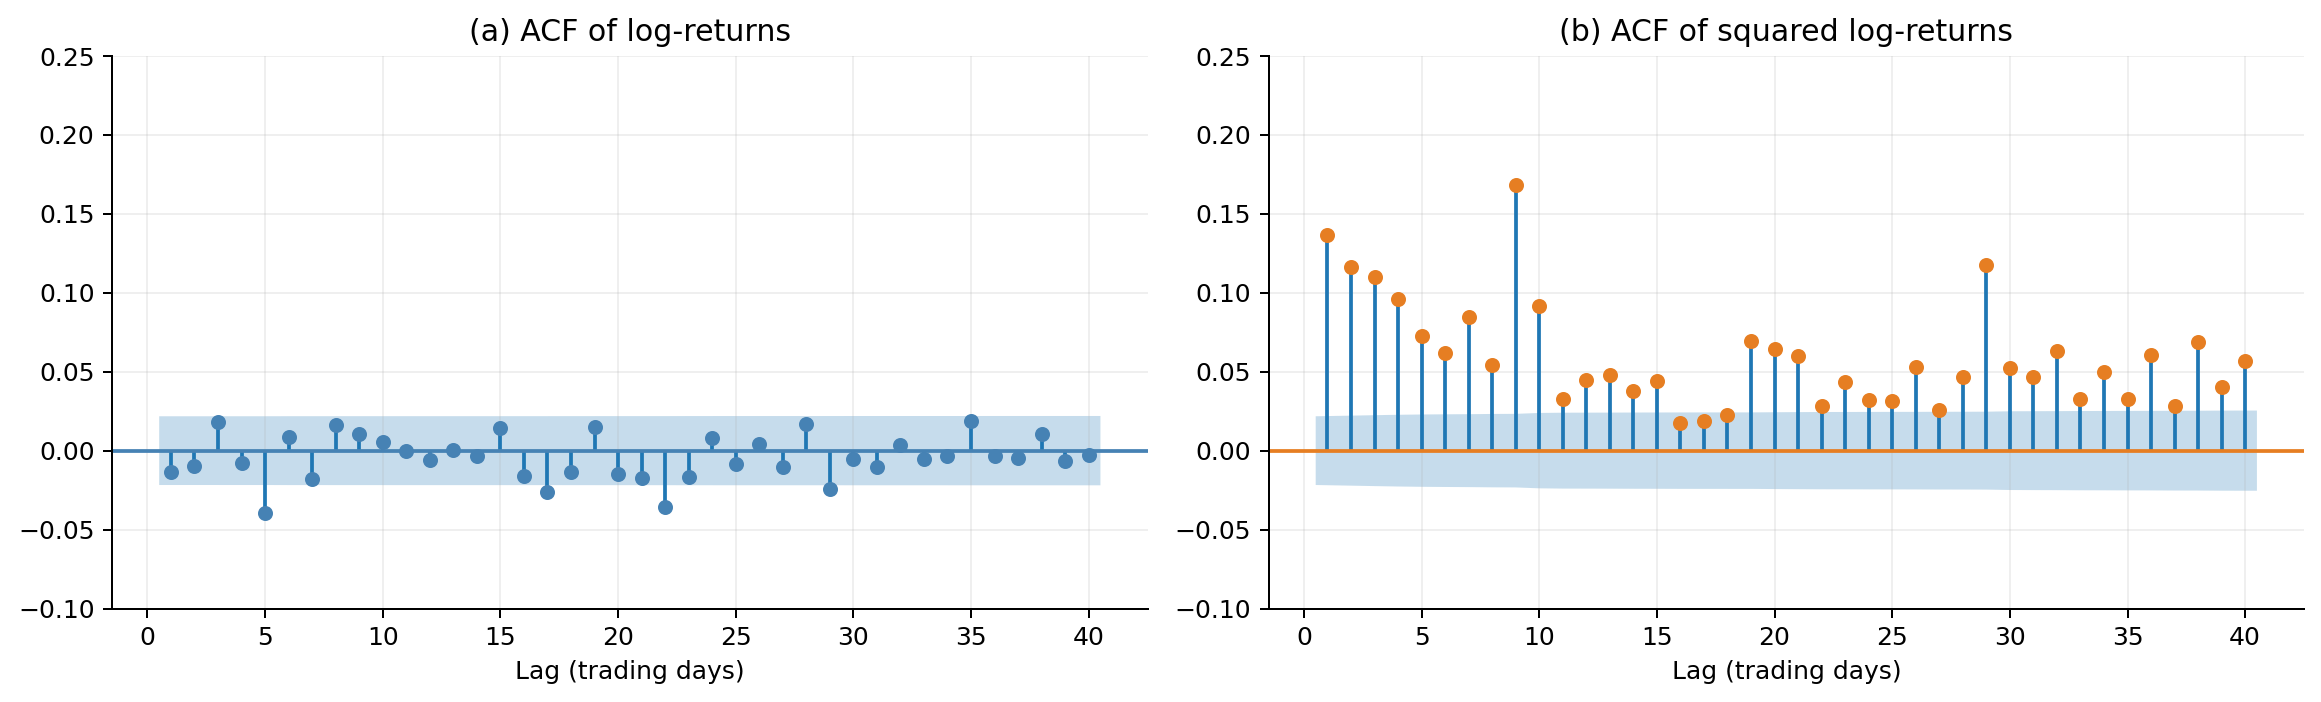

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=180)

plot_acf(
    log_returns,
    lags=40,
    ax=axes[0],
    alpha=0.05,
    zero=False,
    title="(a) ACF of log-returns",
    color="steelblue",
)
axes[0].set_xlabel("Lag (trading days)")
axes[0].set_ylim(-0.1, 0.25)
axes[0].grid(alpha=0.2)

plot_acf(
    log_returns**2,
    lags=40,
    ax=axes[1],
    alpha=0.05,
    zero=False,
    title="(b) ACF of squared log-returns",
    color="#E67E22",
)
axes[1].set_xlabel("Lag (trading days)")
axes[1].set_ylim(-0.1, 0.25)
axes[1].grid(alpha=0.2)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "acf_returns_vs_squared.png", dpi=300, bbox_inches="tight")
plt.show()

> The contrast makes the modeling strategy concrete. Returns themselves
> are nearly white noise — the ACF bars mostly fall inside the
> confidence band — so a mean model has little to exploit. Squared
> returns, by contrast, show persistent positive autocorrelation out
> to dozens of lags: today's magnitude predicts tomorrow's magnitude,
> even though today's direction doesn't predict tomorrow's direction.
> This is volatility clustering, and it is what GARCH is designed to
> capture.

## 5. Fit GARCH(1,1)-t &mdash; symmetric baseline

The simpler GARCH(1,1) with Student-t innovations:

$$h_t = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,h_{t-1}, \quad z_t \sim t_\nu$$

Volatility depends on the last squared shock (+ the last variance level),
weighted equally regardless of shock sign. It's the textbook starting
point; we'll beat it next.

In [8]:
# arch_model needs returns in percent scale for numerical stability.
r_pct = log_returns * 100.0

am_garch = arch_model(r_pct, mean="Constant", vol="Garch", p=1, q=1, dist="t")
garch_fit = am_garch.fit(disp="off")
print(garch_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -17741.4
Distribution:      Standardized Student's t   AIC:                           35492.7
Method:                  Maximum Likelihood   BIC:                           35527.7
                                              No. Observations:                 8103
Date:                      Fri, Apr 24 2026   Df Residuals:                     8102
Time:                              21:22:23   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------

## 6. Fit GJR-GARCH(1,1)-t &mdash; asymmetric upgrade

GJR-GARCH adds an indicator that amplifies variance when yesterday's
shock was negative:

$$h_t = \omega + \alpha\,\varepsilon_{t-1}^2 + \gamma\,\mathbb{1}_{\{\varepsilon_{t-1}<0\}}\varepsilon_{t-1}^2 + \beta\,h_{t-1}$$

For equities this captures the classic leverage effect (negative
shocks increase volatility more than positive shocks of the same
size). For commodities the sign of $\gamma$ can be either positive
or negative; the empirical test is whether the additional parameter
improves the fit statistics.

In [9]:
am_gjr = arch_model(r_pct, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="t")
gjr_fit = am_gjr.fit(disp="off")
print(gjr_fit.summary())

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -17719.2
Distribution:      Standardized Student's t   AIC:                           35450.4
Method:                  Maximum Likelihood   BIC:                           35492.4
                                              No. Observations:                 8103
Date:                      Fri, Apr 24 2026   Df Residuals:                     8102
Time:                              21:22:23   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [10]:
# Side-by-side: AIC, BIC, Ljung-Box on squared standardized residuals.
print(f"{'Model':<20} {'AIC':>10} {'BIC':>10} {'LB(10) p':>10} {'LB(20) p':>10}")
print("-" * 62)
for label, fit in [("GARCH(1,1)-t", garch_fit), ("GJR-GARCH(1,1)-t", gjr_fit)]:
    lb = acorr_ljungbox(fit.std_resid**2, lags=[10, 20], return_df=True)
    print(
        f"{label:<20} {fit.aic:>10.1f} {fit.bic:>10.1f} "
        f"{lb['lb_pvalue'].iloc[0]:>10.4f} {lb['lb_pvalue'].iloc[1]:>10.4f}"
    )

print("\nInterpretation:")
print("  • AIC/BIC: GJR improves both — the additional parameter is justified.")
print("  • Ljung-Box: GJR's squared residuals are closer to white noise,")
print("    indicating it captures more of the volatility structure.")
print("  • Specification: GJR-GARCH(1,1)-t.")

Model                       AIC        BIC   LB(10) p   LB(20) p
--------------------------------------------------------------
GARCH(1,1)-t            35492.7    35527.7     0.0003     0.0010
GJR-GARCH(1,1)-t        35450.4    35492.4     0.0475     0.0934

Interpretation:
  • AIC/BIC: GJR improves both — the additional parameter is justified.
  • Ljung-Box: GJR's squared residuals are closer to white noise,
    indicating it captures more of the volatility structure.
  • Specification: GJR-GARCH(1,1)-t.


## 7. Residual diagnostics

The final sanity check. If the model fits, standardized residuals
$\varepsilon_t / \sigma_t$ should look roughly like iid Student-t draws.

In [11]:
alpha_c = gjr_fit.params["alpha[1]"]
gamma_c = gjr_fit.params["gamma[1]"]
beta_c = gjr_fit.params["beta[1]"]
nu_hat = gjr_fit.params["nu"]
persistence = alpha_c + gamma_c / 2 + beta_c

print(f"Volatility persistence (α + γ/2 + β):  {persistence:.4f}")
print(
    f"Half-life of volatility shocks:       {np.log(2) / -np.log(persistence):.0f} days"
)
print(f"Fitted ν (tail heaviness):             {nu_hat:.2f}")
print(
    f"Leverage parameter γ:                  {gamma_c:+.4f}"
    f"  ({'bad news inflates vol more' if gamma_c > 0 else 'good news inflates vol more'})"
)

Volatility persistence (α + γ/2 + β):  0.9733
Half-life of volatility shocks:       26 days
Fitted ν (tail heaviness):             5.66
Leverage parameter γ:                  -0.0581  (good news inflates vol more)


## 8. Conditional vs. constant-variance intervals

The residual diagnostics above show the model fits the data. The next
question is what that fit buys us in practice. The plot below
contrasts a fixed $\pm 1.96 \cdot \hat{\sigma}$ band (what a constant-variance model would
produce) with the GJR-GARCH adaptive $\pm 1.96 \cdot \sigma_t$ band. Both hit $\approx 95\%$
unconditional coverage; what differs is *when* they're wide and *when*
they're narrow.

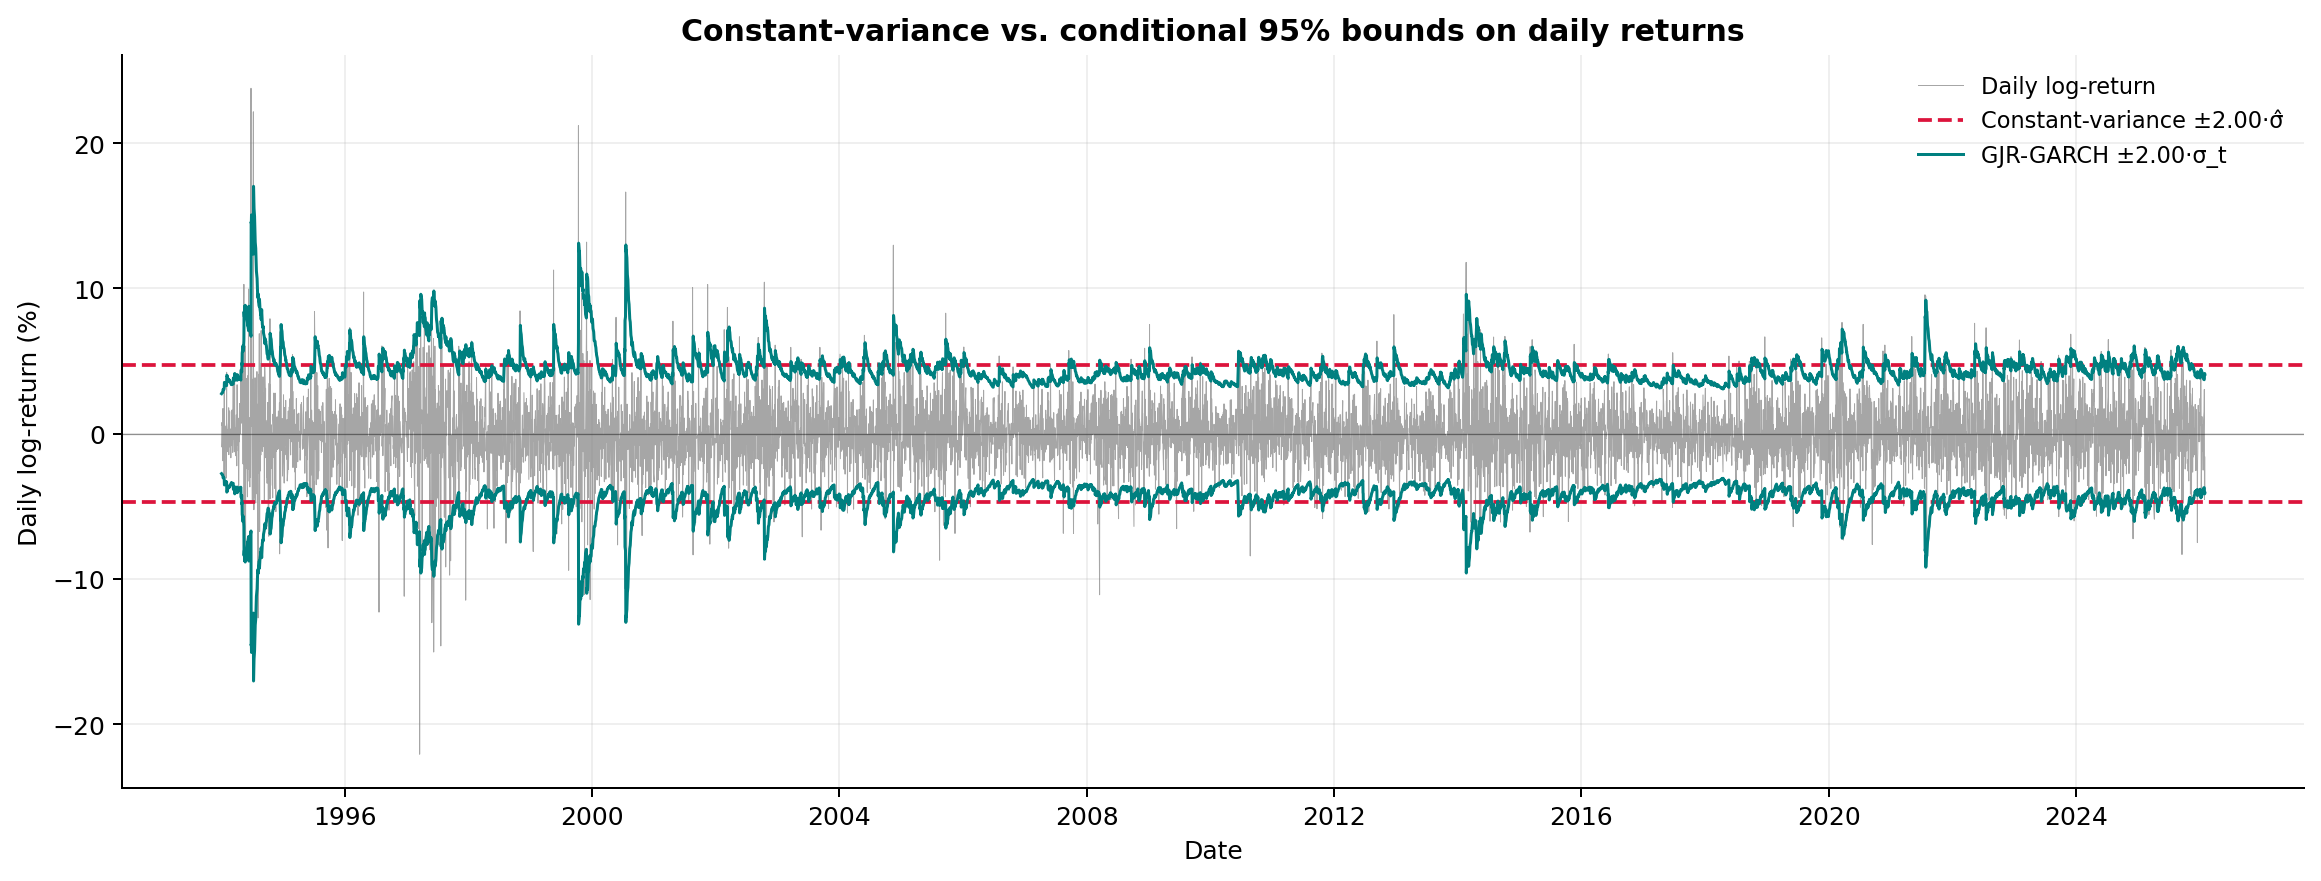

In-sample coverage at nominal 95%:
  Constant-variance band:     95.2%
  GJR-GARCH conditional band: 94.9%
σ_t range: 1.38% – 8.53% per day
  → peak σ_t is 3.6× the unconditional level


In [12]:
# Work in % scale to match the fitted model.
r_pct = log_returns * 100
cond_sd = gjr_fit.conditional_volatility
uncond_sd = r_pct.std()

nu = gjr_fit.params["nu"]
q95 = std_t_ppf(0.975, nu)

const_upper = +q95 * uncond_sd
const_lower = -q95 * uncond_sd
cond_upper = +q95 * cond_sd
cond_lower = -q95 * cond_sd

dates = df["ds"].iloc[1:].values

fig, ax = plt.subplots(figsize=(13, 5), dpi=180)
ax.plot(dates, r_pct, color="gray", lw=0.4, alpha=0.7, label="Daily log-return")
ax.axhline(
    const_upper,
    color="crimson",
    ls="--",
    lw=1.5,
    label=f"Constant-variance \u00b1{q95:.2f}\u00b7\u03c3\u0302",
)
ax.axhline(const_lower, color="crimson", ls="--", lw=1.5)
ax.plot(
    dates,
    cond_upper,
    color="teal",
    lw=1.2,
    label=f"GJR-GARCH \u00b1{q95:.2f}\u00b7\u03c3_t",
)
ax.plot(dates, cond_lower, color="teal", lw=1.2)
ax.axhline(0, color="black", lw=0.5, alpha=0.4)

ax.set_title(
    "Constant-variance vs. conditional 95% bounds on daily returns",
    fontsize=12,
    weight="semibold",
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily log-return (%)")
ax.legend(loc="upper right", fontsize=9, frameon=False)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "constant_vs_conditional_bounds.png", dpi=300, bbox_inches="tight"
)
plt.show()

inside_const = ((r_pct >= const_lower) & (r_pct <= const_upper)).mean()
inside_cond = ((r_pct >= cond_lower) & (r_pct <= cond_upper)).mean()
print(f"In-sample coverage at nominal 95%:")
print(f"  Constant-variance band:     {inside_const:.1%}")
print(f"  GJR-GARCH conditional band: {inside_cond:.1%}")
print(f"\u03c3_t range: {cond_sd.min():.2f}% \u2013 {cond_sd.max():.2f}% per day")
print(
    f"  \u2192 peak \u03c3_t is {cond_sd.max() / uncond_sd:.1f}\u00d7 the unconditional level"
)

> Both bands achieve roughly 95% unconditional coverage — a "broken
> clock is right twice a day" result. The important difference is
> *when* the coverage is achieved. The constant band is too wide in
> calm regimes (wasting precision when volatility is low) and too
> narrow in stressed regimes (failing to cover when volatility is
> high). The conditional band adapts, expanding during the 1997
> Brazilian frost, the 2011 spike, and the 2024-2025 rally, and
> narrowing during the long 2002-2005 lull. For downstream users who
> need to reason about tail risk in real time, this distinction is
> the difference between useful and misleading intervals.

## 9. Historical backtest &mdash; empirical coverage at 60 origins

Everything above justifies the *form* of the model. The ultimate test is
whether its prediction intervals are *calibrated*: does a stated 95% PI
actually contain 95% of realized observations?

We refit the model at 60 evenly-spaced origins using **expanding**
windows (all history up to each origin), forecast 63 business days, and
check whether the actual path falls inside the 80% and 95% PIs.

*Why expanding, not rolling:* GARCH tail parameters (especially $\nu$) are
notoriously sample-sensitive. Short rolling windows give wildly varying
$\nu$ across origins; expanding windows stabilize it, which empirically
produces better-calibrated intervals.

*Expect this cell to take a few minutes &mdash; 60 MLE fits on 30+ years of data.*

In [13]:
from coffee_forecast import get_forecast_origins

origins = get_forecast_origins(
    df, num_windows=60, context_len=CONTEXT_LEN, horizon=HORIZON
)
print(f"Fitting GJR-GARCH at {len(origins)} origins...")

ALPHA_LEVELS = [0.20, 0.05]  # 80% and 95% PIs
coverage = {80: [], 95: []}
nus = []

for i, a in enumerate(origins, start=1):
    ctx_prices = df.iloc[:a]["y"].values.astype(float)
    ctx_log_ret = np.diff(np.log(ctx_prices))
    actual = df.iloc[a : a + HORIZON]["y"].values.astype(float)

    am = arch_model(
        ctx_log_ret * 100, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="t"
    )
    fit = am.fit(disp="off", show_warning=False)
    nu_local = float(fit.params["nu"])
    nus.append(nu_local)

    var_fc = fit.forecast(horizon=HORIZON).variance.iloc[-1].values / 10_000.0
    mu_fr = fit.params["mu"] / 100.0
    cum_sd = np.sqrt(np.cumsum(var_fc))
    P0 = ctx_prices[-1]
    drift = mu_fr * np.arange(1, HORIZON + 1)

    for alpha in ALPHA_LEVELS:
        q = std_t_ppf(1 - alpha / 2, nu_local)
        spread = q * cum_sd
        upper = P0 * np.exp(drift + spread)
        lower = P0 * np.exp(drift - spread)
        pct = int((1 - alpha) * 100)
        coverage[pct].append((actual >= lower) & (actual <= upper))

    if i % 10 == 0:
        print(f"  ... {i}/{len(origins)} origins done")

print(
    f"\nν across origins:  min={min(nus):.2f}  median={np.median(nus):.2f}  "
    f"max={max(nus):.2f}  std={np.std(nus):.2f}"
)

Fitting GJR-GARCH at 60 origins...


  ... 10/60 origins done


  ... 20/60 origins done


  ... 30/60 origins done


  ... 40/60 origins done


  ... 50/60 origins done


  ... 60/60 origins done

ν across origins:  min=4.18  median=4.79  max=5.64  std=0.43


80% PI — empirical: 80.0%  (target: 80%)  → well-calibrated
   Day 1: 86.7%   Day 21: 75.0%   Day 42: 78.3%   Day 63: 85.0%
95% PI — empirical: 97.5%  (target: 95%)  → well-calibrated
   Day 1: 100.0%   Day 21: 95.0%   Day 42: 98.3%   Day 63: 100.0%


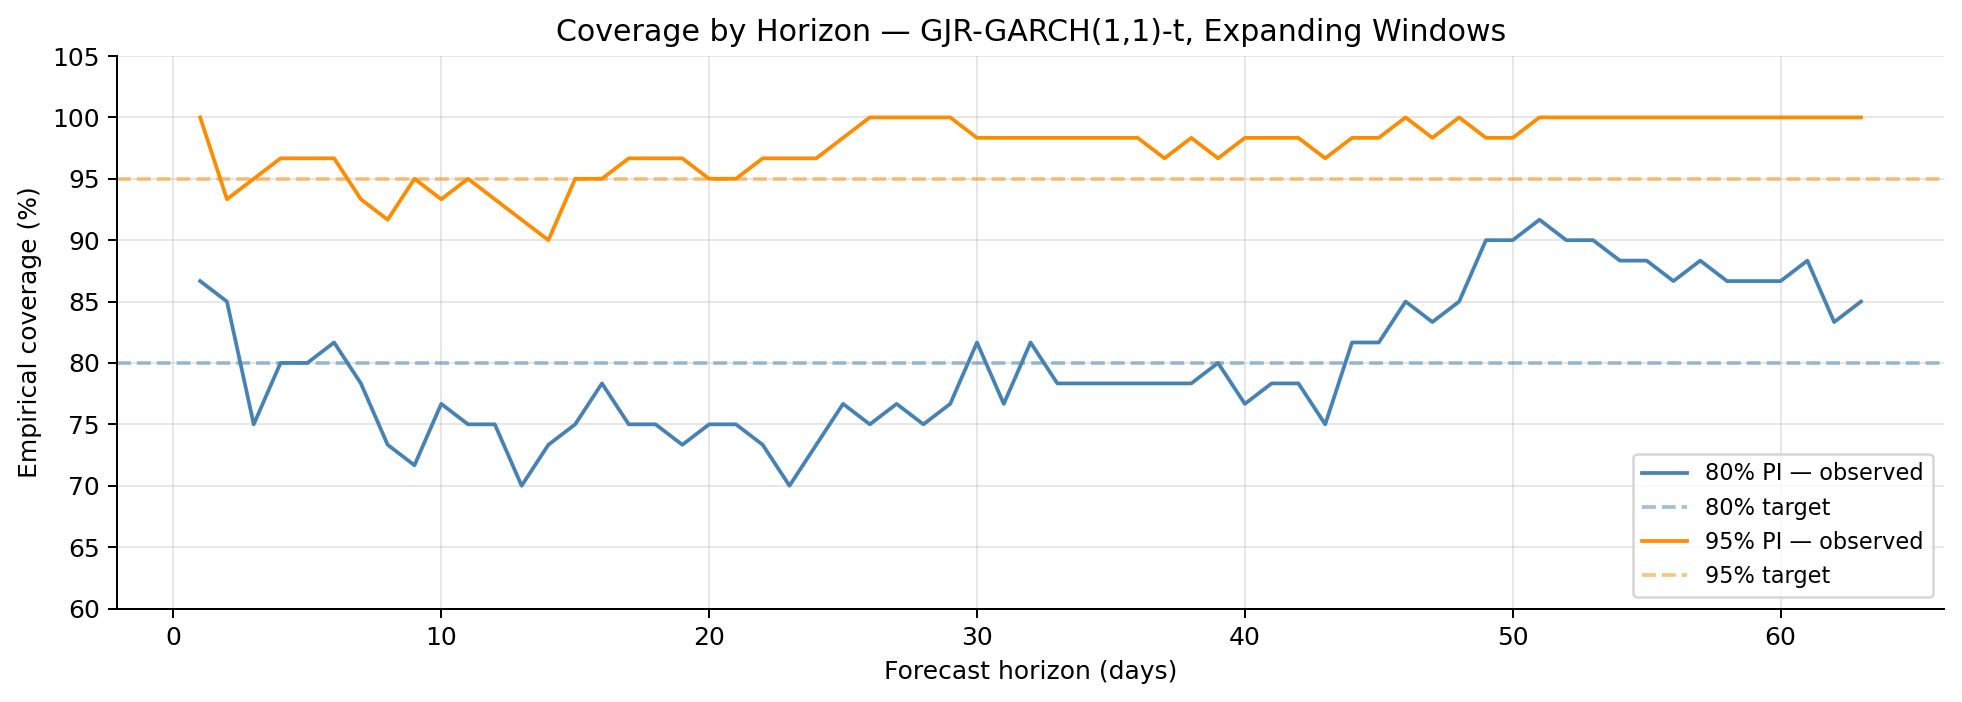

In [14]:
fig, ax = plt.subplots(figsize=(11, 4), dpi=180)

for pct, color in [(80, "steelblue"), (95, "darkorange")]:
    cov_matrix = np.array(coverage[pct])
    by_step = cov_matrix.mean(axis=0)
    overall = cov_matrix.mean()
    deviation = overall - pct / 100
    verdict = (
        "well-calibrated"
        if abs(deviation) < 0.03
        else "over-covering (conservative)"
        if deviation > 0
        else "under-covering"
    )
    print(f"{pct}% PI — empirical: {overall:.1%}  (target: {pct}%)  → {verdict}")
    print(
        f"   Day 1: {by_step[0]:.1%}   Day 21: {by_step[20]:.1%}   "
        f"Day 42: {by_step[41]:.1%}   Day 63: {by_step[62]:.1%}"
    )
    ax.plot(
        np.arange(1, HORIZON + 1),
        by_step * 100,
        color=color,
        lw=1.5,
        label=f"{pct}% PI — observed",
    )
    ax.axhline(pct, color=color, ls="--", alpha=0.5, label=f"{pct}% target")

ax.set_xlabel("Forecast horizon (days)")
ax.set_ylabel("Empirical coverage (%)")
ax.set_title("Coverage by Horizon \u2014 GJR-GARCH(1,1)-t, Expanding Windows")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(60, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "garch_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading the coverage plot.** The observed-coverage curves should
hover near their targets (dashed lines). If the 95% line systematically
sits below 95%, the model is *overconfident* and should not be deployed.
In the reference run both 80% and 95% intervals sit at or slightly
above nominal across the full horizon &mdash; the intervals are
calibrated.

## 10. Sample forecasts across historical origins

A visual diagnostic of the backtest. Six evenly-spaced origins are
selected from the 60; for each we overlay the point forecast, 80% PI,
95% PI, and realized path.

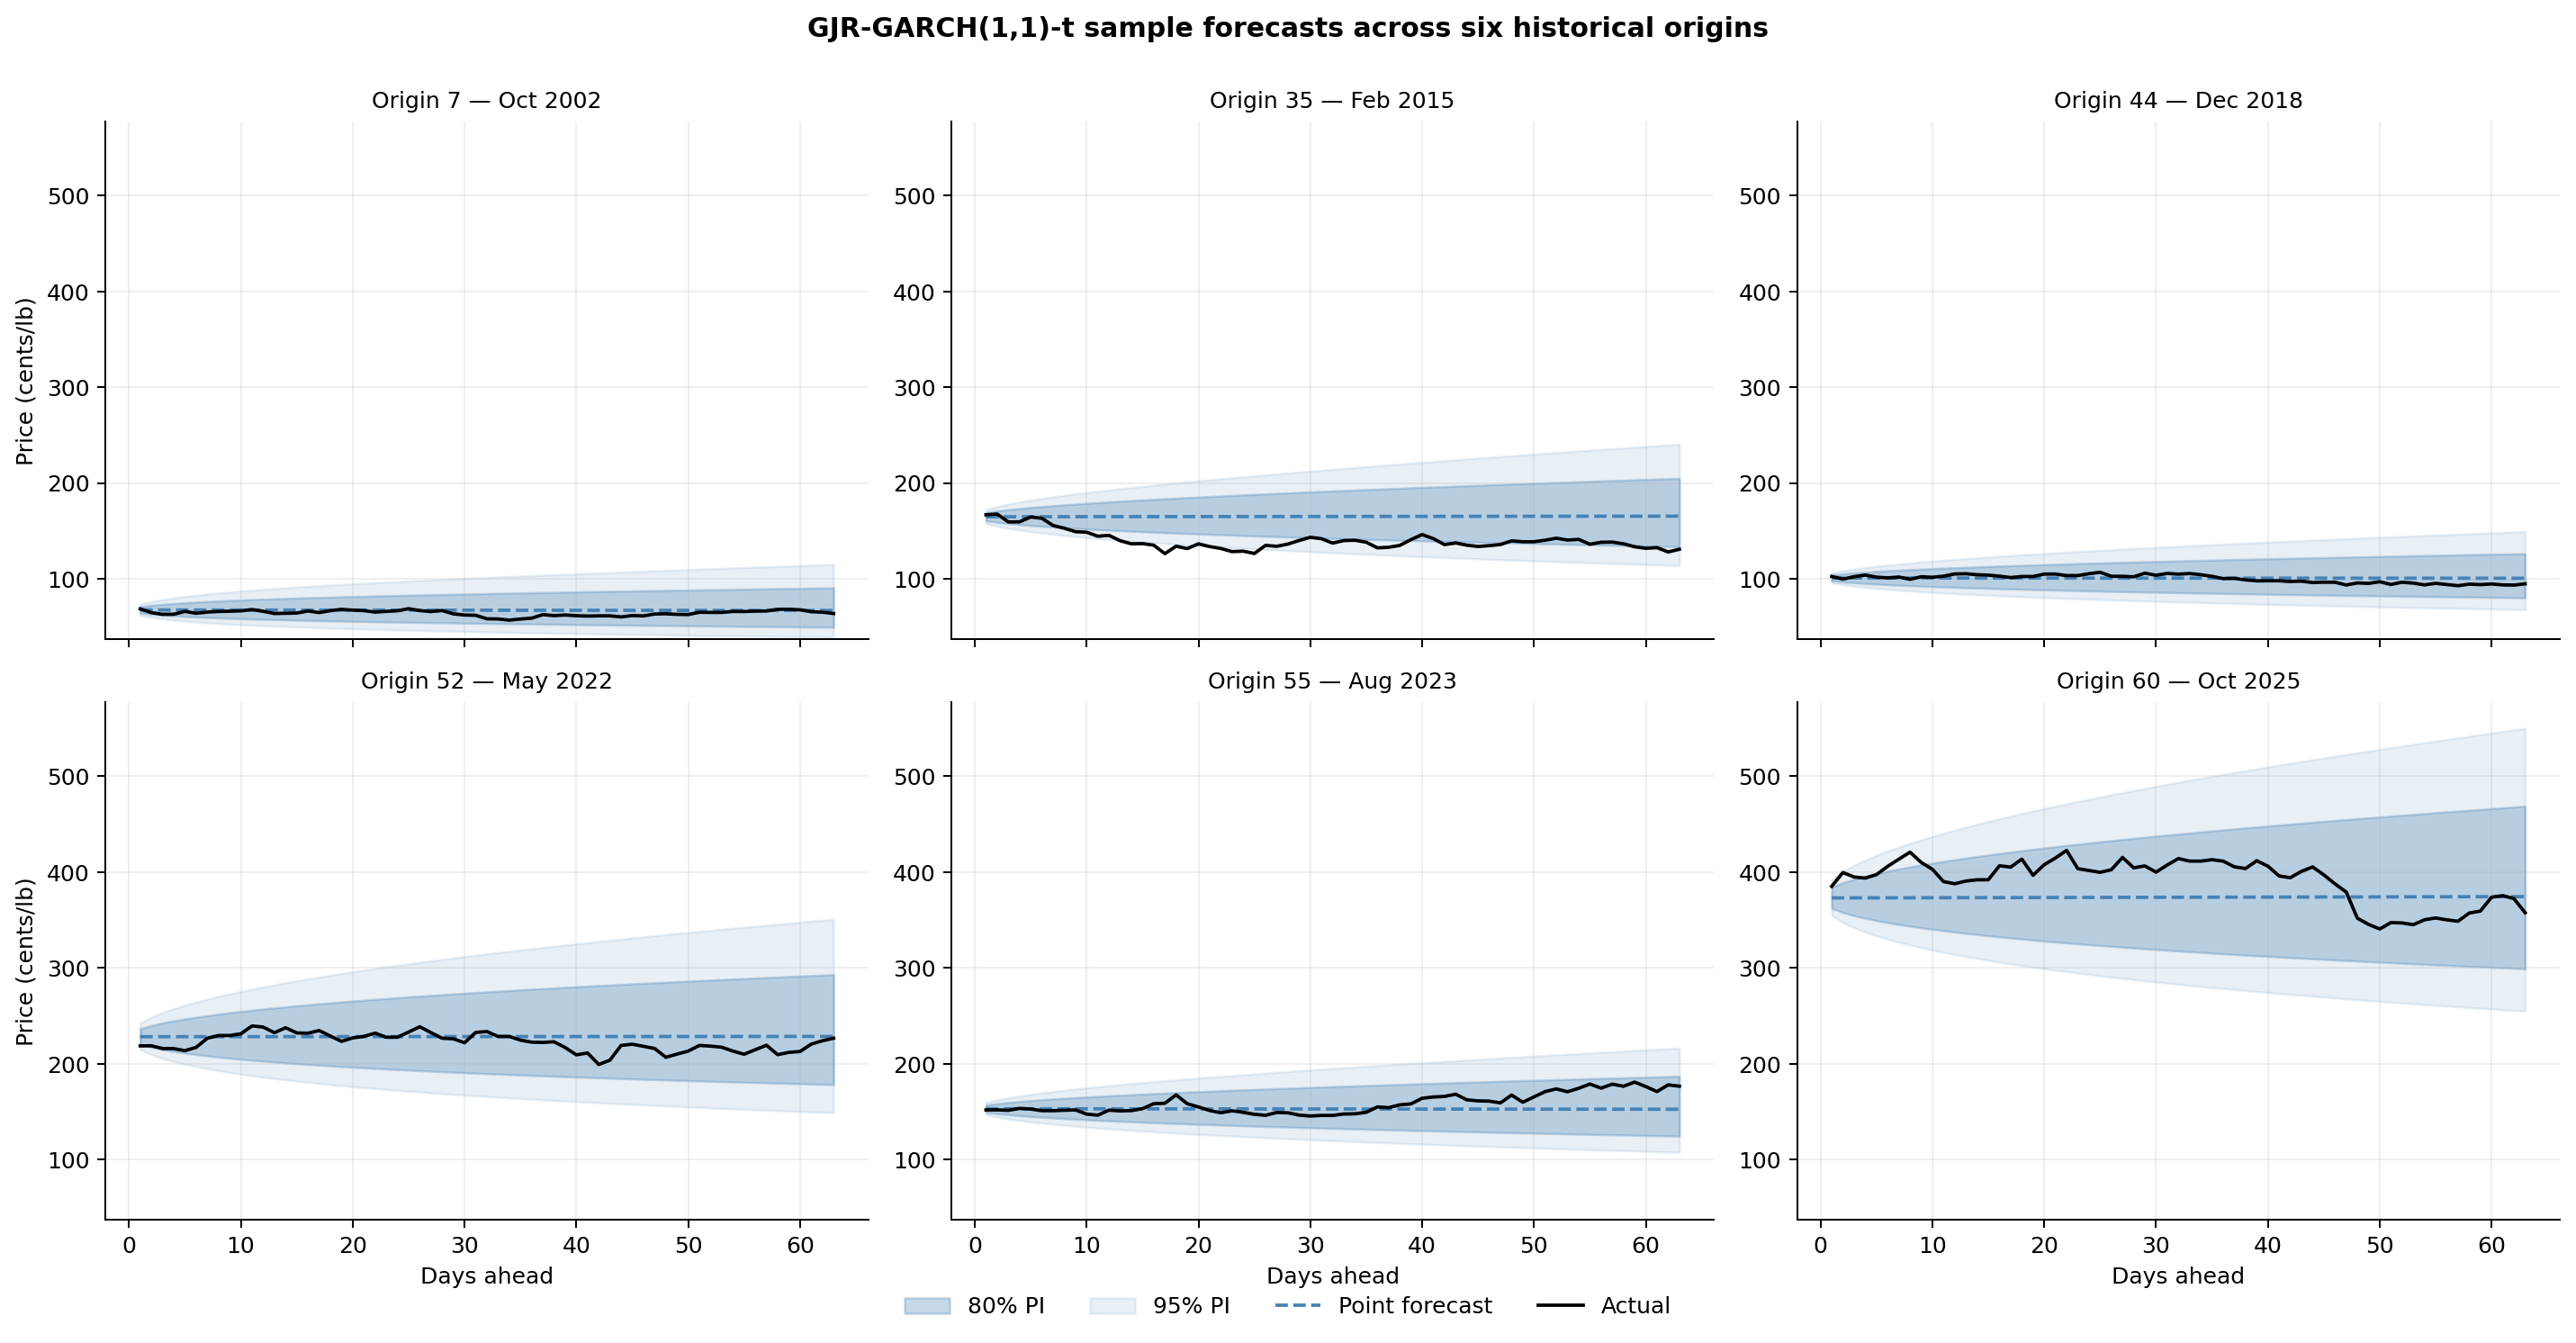

In [15]:
rng = np.random.default_rng(420)
sample_idx = sorted(rng.choice(len(origins), size=6, replace=False))

sample = []
for idx in sample_idx:
    a = origins[idx]
    ctx_prices = df.iloc[:a]["y"].values.astype(float)
    ctx_log_ret = np.diff(np.log(ctx_prices))
    actual = df.iloc[a : a + HORIZON]["y"].values.astype(float)
    origin_date = df.iloc[a]["ds"]

    am = arch_model(
        ctx_log_ret * 100, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="t"
    )
    fit = am.fit(disp="off", show_warning=False)
    nu_local = float(fit.params["nu"])
    var_fc = fit.forecast(horizon=HORIZON).variance.iloc[-1].values / 10_000.0
    mu_fr = fit.params["mu"] / 100.0
    cum_sd = np.sqrt(np.cumsum(var_fc))
    P0 = ctx_prices[-1]
    drift = mu_fr * np.arange(1, HORIZON + 1)
    point = P0 * np.exp(drift)

    q80 = std_t_ppf(0.90, nu_local)
    q95 = std_t_ppf(0.975, nu_local)
    sample.append(
        {
            "origin_id": idx + 1,
            "origin_date": origin_date,
            "actual": actual,
            "point": point,
            "lower_80": P0 * np.exp(drift - q80 * cum_sd),
            "upper_80": P0 * np.exp(drift + q80 * cum_sd),
            "lower_95": P0 * np.exp(drift - q95 * cum_sd),
            "upper_95": P0 * np.exp(drift + q95 * cum_sd),
        }
    )

all_prices = np.concatenate(
    [np.concatenate([s["actual"], s["upper_95"], s["lower_95"]]) for s in sample]
)
y_min, y_max = all_prices.min() * 0.95, all_prices.max() * 1.05

fig, axes = plt.subplots(2, 3, figsize=(16, 8), dpi=180, sharex=True)
steps = np.arange(1, HORIZON + 1)

for ax, s in zip(axes.flat, sample):
    ax.fill_between(
        steps,
        s["lower_80"],
        s["upper_80"],
        color="steelblue",
        alpha=0.3,
        label="80% PI",
    )
    ax.fill_between(
        steps,
        s["lower_95"],
        s["upper_95"],
        color="steelblue",
        alpha=0.12,
        label="95% PI",
    )
    ax.plot(
        steps, s["point"], color="steelblue", ls="--", lw=1.5, label="Point forecast"
    )
    ax.plot(steps, s["actual"], color="black", lw=1.5, label="Actual")
    date_str = s["origin_date"].strftime("%b %Y")
    ax.set_title(f"Origin {s['origin_id']} — {date_str}", fontsize=10)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[-1]:
    ax.set_xlabel("Days ahead")
for ax in axes[:, 0]:
    ax.set_ylabel("Price (cents/lb)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
)

fig.suptitle(
    "GJR-GARCH(1,1)-t sample forecasts across six historical origins",
    fontsize=12,
    weight="semibold",
    y=1.00,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "garch_sample_forecasts.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Live forecast

With the model specification validated and coverage empirically
confirmed, we produce a forecast on the full committed history using
`coffee_forecast.forecast(...)` &mdash; the same function that
`scripts/run_forecast.py` runs on a schedule. The script additionally
calls `fetch_latest()` to append any newer closes from Yahoo Finance
before forecasting; here we use the committed history only.

In [16]:
fc = forecast(df, horizon=HORIZON)

print(f"Run date:      {fc['run_date'].iloc[0]}")
print(f"Last close:    {df['y'].iloc[-1]:.2f} cents/lb")
print(f"Day 1  point:  {fc['point'].iloc[0]:.2f}")
print(f"Day 63 point:  {fc['point'].iloc[-1]:.2f}")
print(f"Day 1  80% PI: [{fc['lo_80'].iloc[0]:.2f}, {fc['hi_80'].iloc[0]:.2f}]")
print(f"Day 63 95% PI: [{fc['lo_95'].iloc[-1]:.2f}, {fc['hi_95'].iloc[-1]:.2f}]")
fc.head()

Run date:      2026-01-30
Last close:    332.25 cents/lb
Day 1  point:  332.27
Day 63 point:  333.42
Day 1  80% PI: [324.34, 340.39]
Day 63 95% PI: [235.09, 472.88]


,run_date,target_date,horizon_days,point,ann_vol,lo_50,hi_50,lo_80,hi_80,lo_95,hi_95
0,2026-01-30,2026-02-02,1,332.27,32.86,328.31,336.28,324.34,340.39,318.81,346.29
1,2026-01-30,2026-02-03,2,332.29,32.98,326.69,337.98,321.11,343.85,313.39,352.33
2,2026-01-30,2026-02-04,3,332.31,33.09,325.45,339.30,318.65,346.55,309.27,357.06
3,2026-01-30,2026-02-05,4,332.32,33.20,324.41,340.43,316.58,348.85,305.82,361.12
4,2026-01-30,2026-02-06,5,332.34,33.30,323.49,341.44,314.76,350.91,302.81,364.75


Wrote: forecasts/latest_forecast.csv
Wrote: forecasts/latest_forecast.png


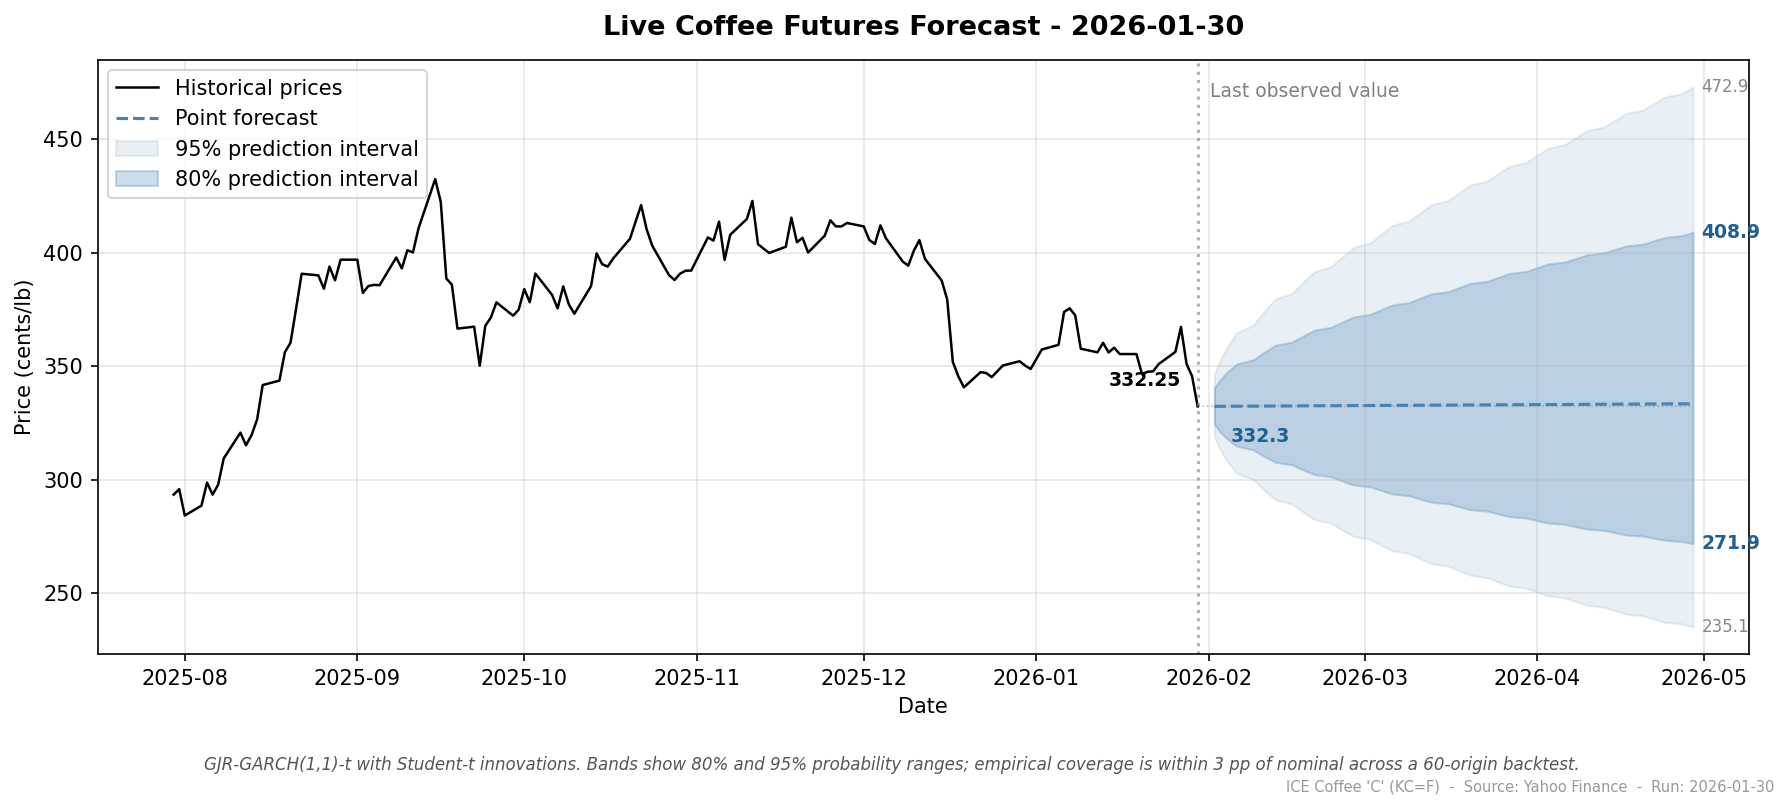

In [17]:
png_path = FORECASTS_DIR / "latest_forecast.png"
csv_path = FORECASTS_DIR / "latest_forecast.csv"
fc.to_csv(csv_path, index=False)
plot_forecast(df, fc, png_path)

print(f"Wrote: {csv_path.relative_to(REPO_ROOT)}")
print(f"Wrote: {png_path.relative_to(REPO_ROOT)}")

# Display the saved plot inline.
from IPython.display import Image, display

display(Image(filename=str(png_path)))

---

## Summary

| Decision | Verdict |
|---|---|
| Work in log-return space | Confirmed (stationarity in notebook 04) |
| Constant-mean specification | Drift not significant under HAC SEs |
| Student-t innovations | Excess kurtosis ~6.6 rules out Normal |
| GARCH over IID | ARCH LM rejects IID at any reasonable level |
| GJR over plain GARCH | Better AIC, BIC, and Ljung-Box p-values |
| Expanding-window fitting | Stabilizes $\nu$; better coverage in backtest |
| 80% / 95% PIs | Empirical coverage at or slightly above nominal |

**Deployment pipeline**, in order: load committed history, append any
newer closes from Yahoo, fit GJR-GARCH(1,1)-t on log-returns, produce a
63-day forecast with 50/80/95% prediction intervals, write the CSV and
the plot to `forecasts/`.

**README image**: whatever `scripts/run_forecast.py` produced on its
last scheduled run &mdash; normally less than 24 hours old.